In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor']   = '#FAFAFA'

TICKERS = ['AAPL', 'AMZN', 'GOOGL', 'META', 'NFLX', 'NVDA']
TICKER_COLORS = {
    'AAPL':'#1f77b4', 'AMZN':'#ff7f0e', 'GOOGL':'#2ca02c',
    'META':'#9467bd', 'NFLX':'#e377c2', 'NVDA':'#17becf'
}
UP_COLOR   = '#2E7D32'
DOWN_COLOR = '#C62828'
BG         = '#FAFAFA'

# Load
prices    = pd.read_csv('stock_prices_6tickers.csv')
sentiment = pd.read_csv('sentiment_daily_6tickers.csv')

prices['date']            = pd.to_datetime(prices['date']).dt.tz_localize(None)
sentiment['trading_date'] = pd.to_datetime(sentiment['trading_date']).dt.tz_localize(None)

# Join
df = prices.merge(sentiment, left_on=['ticker','date'],
                  right_on=['ticker','trading_date'], how='left')
df = df.drop(columns=['trading_date'])
df['target']   = (df.groupby('ticker')['close_price']
                    .shift(-1) > df['close_price']).astype(float)
df['correct']  = ((df['avg_finbert'] > 0).astype(int) == df['target']).astype(int)
df['month']    = df['date'].dt.to_period('M').astype(str)
df_clean       = df.dropna(subset=['target','avg_finbert']).copy()

print(f'Loaded {len(df):,} rows')
print(f'Usable: {len(df_clean):,} rows')
print('Ready')

Loaded 3,126 rows
Usable: 2,776 rows
Ready


## Question 1 — How did each stock price move over 2 years?

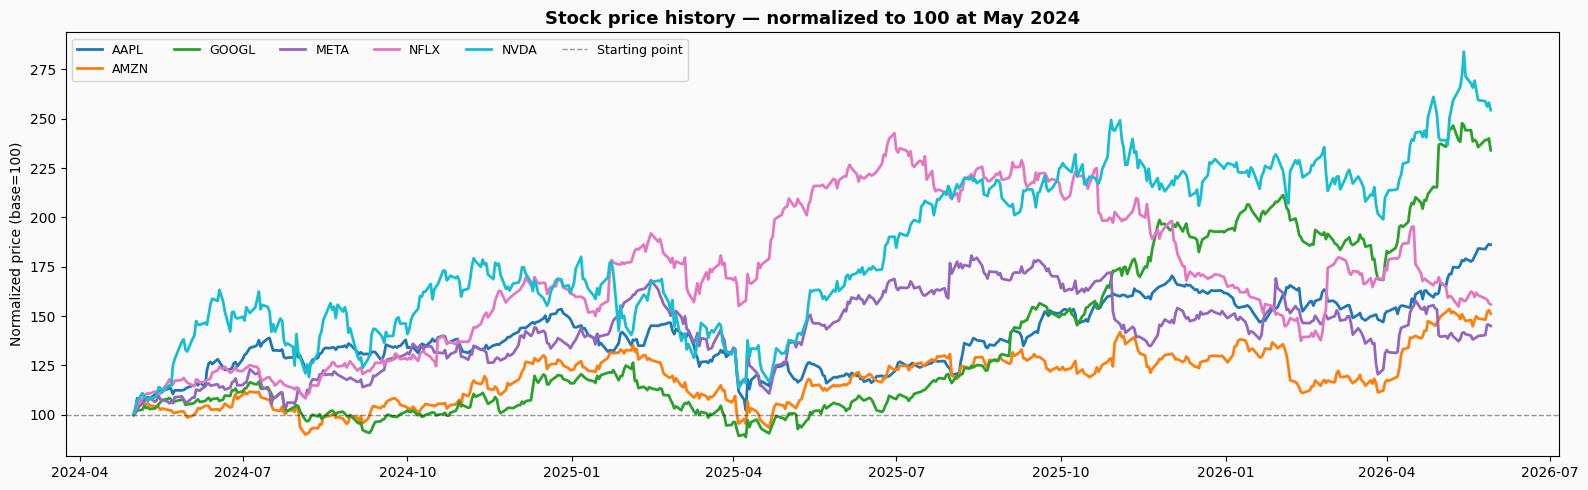

Total return per ticker:
  AAPL: +86.2%
  AMZN: +51.2%
  GOOGL: +134.0%
  META: +45.0%
  NFLX: +55.9%
  NVDA: +154.4%


In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

for ticker in TICKERS:
    d    = prices[prices['ticker']==ticker].sort_values('date')
    norm = d['close_price'] / d['close_price'].iloc[0] * 100
    ax.plot(d['date'], norm, label=ticker,
            color=TICKER_COLORS[ticker], linewidth=2)

ax.axhline(y=100, color='black', linewidth=1,
           linestyle='--', alpha=0.4, label='Starting point')
ax.set_title('Stock price history — normalized to 100 at May 2024',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Normalized price (base=100)')
ax.legend(ncol=6, fontsize=9)
plt.tight_layout()
plt.show()

print('Total return per ticker:')
for ticker in TICKERS:
    d   = prices[prices['ticker']==ticker].sort_values('date')
    ret = (d['close_price'].iloc[-1] / d['close_price'].iloc[0] - 1) * 100
    print(f'  {ticker}: {ret:+.1f}%')

## Question 2 — Are UP and DOWN days balanced?

check if the dataset is biased

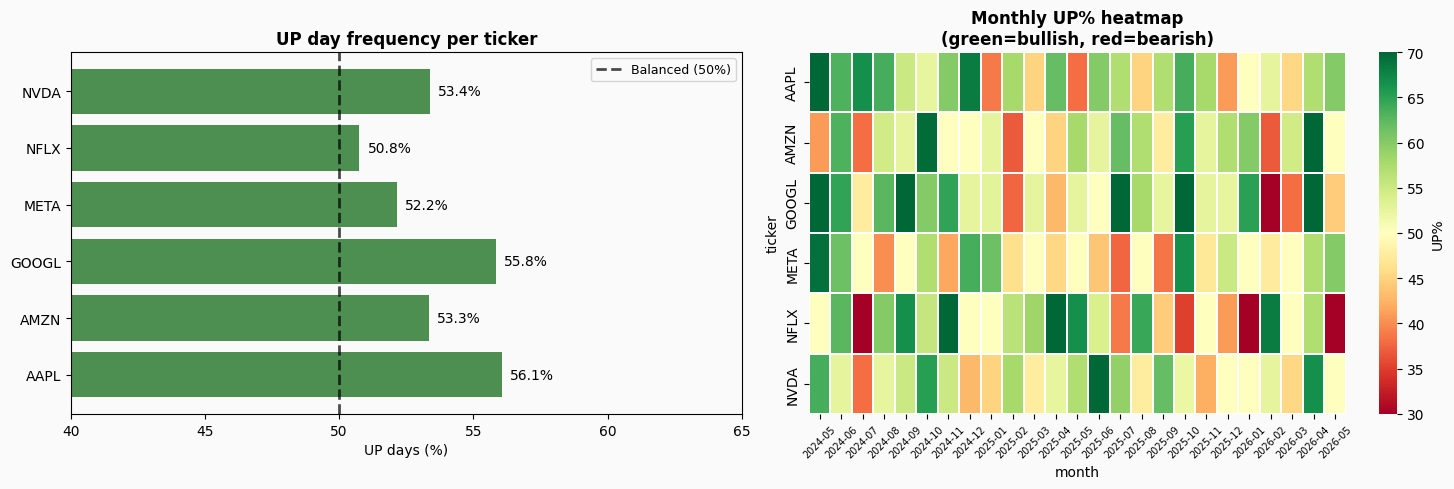

UP day % per ticker:
  AAPL: 56.1% (UP-biased)
  AMZN: 53.3% (Balanced)
  GOOGL: 55.8% (UP-biased)
  META: 52.2% (Balanced)
  NFLX: 50.8% (Balanced)
  NVDA: 53.4% (Balanced)

  Overall: 53.6% UP days


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left — UP% per ticker
ax = axes[0]
up_pcts = [df_clean[df_clean['ticker']==t]['target'].mean()*100
           for t in TICKERS]
colors  = [UP_COLOR if u>=50 else DOWN_COLOR for u in up_pcts]
bars    = ax.barh(TICKERS, up_pcts, color=colors, alpha=0.85)
ax.axvline(x=50, color='black', linewidth=2,
           linestyle='--', alpha=0.7, label='Balanced (50%)')
ax.set_xlabel('UP days (%)')
ax.set_title('UP day frequency per ticker', fontweight='bold')
ax.set_xlim(40, 65)
ax.legend(fontsize=9)
for bar, val in zip(bars, up_pcts):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

# Right — monthly UP% heatmap
ax = axes[1]
pivot = df_clean.pivot_table(values='target', index='ticker',
                              columns='month', aggfunc='mean')*100
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', center=50,
            vmin=30, vmax=70, cbar_kws={'label':'UP%'},
            linewidths=0.3, linecolor='white')
ax.set_title('Monthly UP% heatmap\n(green=bullish, red=bearish)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

print('UP day % per ticker:')
for ticker, pct in zip(TICKERS, up_pcts):
    bias = 'UP-biased' if pct>55 else 'DOWN-biased' if pct<45 else 'Balanced'
    print(f'  {ticker}: {pct:.1f}% ({bias})')
print(f'\n  Overall: {sum(up_pcts)/len(up_pcts):.1f}% UP days')

## Question 3 — How much news data do we have per ticker?

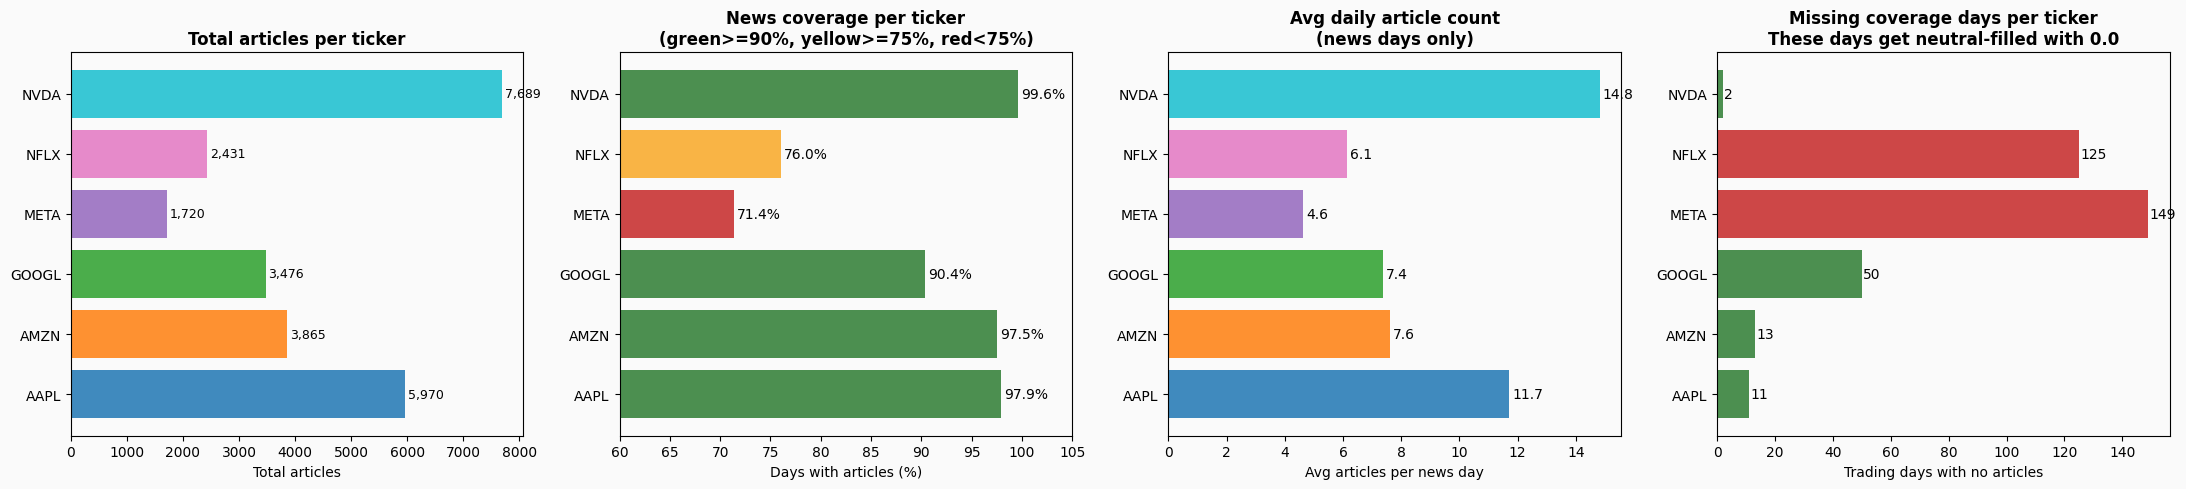

Coverage summary:
Ticker     Articles   Coverage    Avg/day    Missing
----------------------------------------------------
AAPL          5,970      97.9%      11.7         11
AMZN          3,865      97.5%       7.6         13
GOOGL         3,476      90.4%       7.4         50
META          1,720      71.4%       4.6        149
NFLX          2,431      76.0%       6.1        125
NVDA          7,689      99.6%      14.8          2


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Total articles
ax = axes[0]
totals = [int(df_clean[df_clean['ticker']==t]['article_count'].sum())
          for t in TICKERS]
bars = ax.barh(TICKERS, totals,
               color=[TICKER_COLORS[t] for t in TICKERS], alpha=0.85)
ax.set_xlabel('Total articles')
ax.set_title('Total articles per ticker', fontweight='bold')
for bar, val in zip(bars, totals):
    ax.text(val+50, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

# Coverage %
ax = axes[1]
coverage = [(df[df['ticker']==t]['avg_finbert'].notna()).mean()*100
            for t in TICKERS]
colors_c = [UP_COLOR if c>=90 else '#F9A825' if c>=75 else DOWN_COLOR
            for c in coverage]
bars2 = ax.barh(TICKERS, coverage, color=colors_c, alpha=0.85)
ax.set_xlabel('Days with articles (%)')
ax.set_title('News coverage per ticker\n(green>=90%, yellow>=75%, red<75%)',
             fontweight='bold')
ax.set_xlim(60, 105)
for bar, val in zip(bars2, coverage):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

# Avg articles per day
ax = axes[2]
avg_arts = [df_clean[(df_clean['ticker']==t) &
                     (df_clean['article_count']>0)]['article_count'].mean()
            for t in TICKERS]
bars3 = ax.barh(TICKERS, avg_arts,
                color=[TICKER_COLORS[t] for t in TICKERS], alpha=0.85)
ax.set_xlabel('Avg articles per news day')
ax.set_title('Avg daily article count\n(news days only)',
             fontweight='bold')
for bar, val in zip(bars3, avg_arts):
    ax.text(val+0.1, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)

# Missing days
ax = axes[3]
missing = [df[df['ticker']==t]['avg_finbert'].isna().sum()
           for t in TICKERS]
colors_m = [DOWN_COLOR if m>100 else '#F9A825' if m>50 else UP_COLOR
            for m in missing]
bars4 = ax.barh(TICKERS, missing, color=colors_m, alpha=0.85)
ax.set_xlabel('Trading days with no articles')
ax.set_title('Missing coverage days per ticker\n'
             'These days get neutral-filled with 0.0',
             fontweight='bold')
for bar, val in zip(bars4, missing):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Coverage summary:')
print(f"{'Ticker':<8} {'Articles':>10} {'Coverage':>10} "
      f"{'Avg/day':>10} {'Missing':>10}")
print('-'*52)
for t, tot, cov, avg, mis in zip(TICKERS, totals, coverage,
                                  avg_arts, missing):
    print(f'{t:<8} {tot:>10,} {cov:>9.1f}% '
          f'{avg:>9.1f} {mis:>10}')

## Q3b - Does more data = better accuracy?

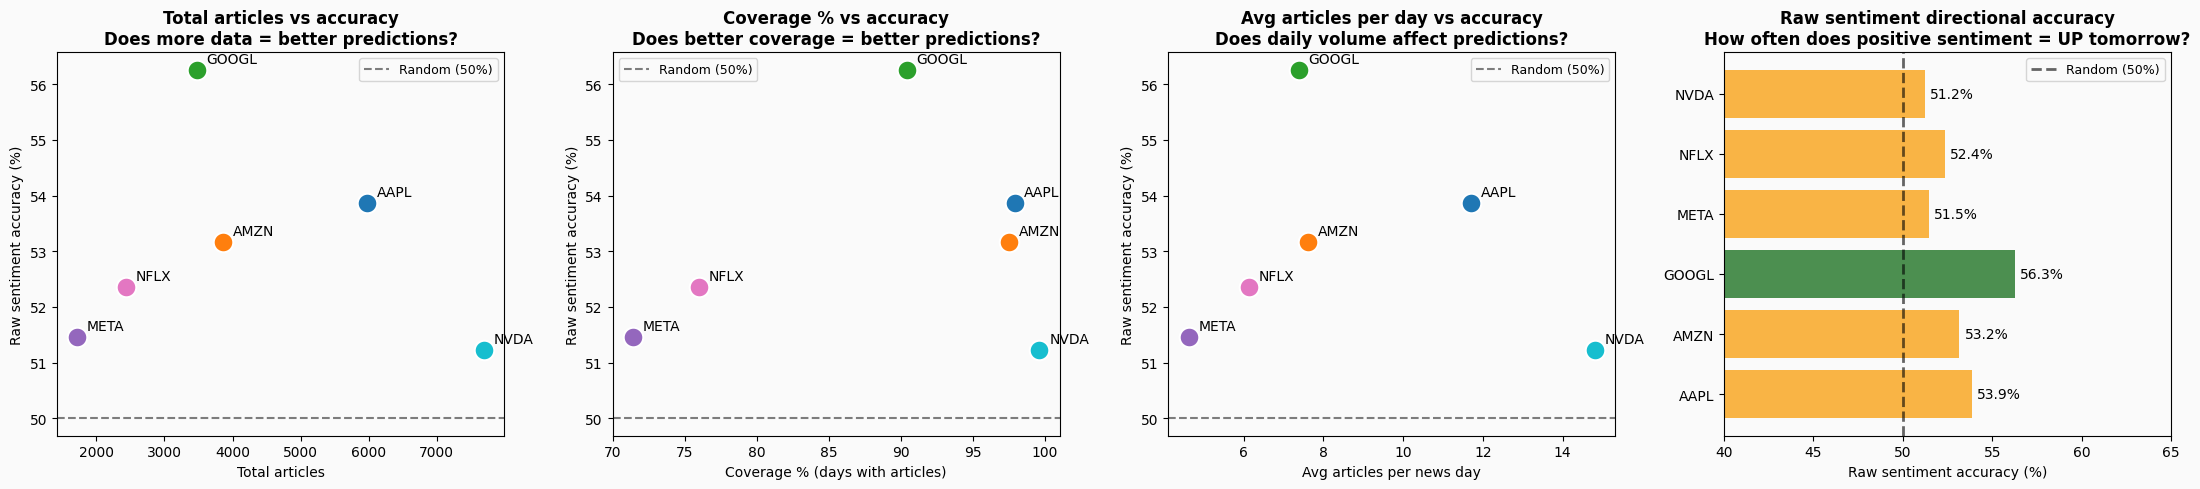

Coverage vs accuracy summary:
Ticker     Articles   Coverage    Avg/day    Raw acc
----------------------------------------------------
AAPL          5,970      97.9%      11.7      53.9%
AMZN          3,865      97.5%       7.6      53.2%
GOOGL         3,476      90.4%       7.4      56.3%
META          1,720      71.4%       4.6      51.5%
NFLX          2,431      76.0%       6.1      52.4%
NVDA          7,689      99.6%      14.8      51.2%


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Calculate raw sentiment accuracy per ticker
raw_acc = {}
for ticker in TICKERS:
    d     = df_clean[df_clean['ticker']==ticker]
    d_sig = d[d['avg_finbert'].abs() > 0.05]
    raw_acc[ticker] = d_sig['correct'].mean()*100 if len(d_sig)>0 else 50.0

totals   = {t: int(df_clean[df_clean['ticker']==t]['article_count'].sum())
            for t in TICKERS}
coverage = {t: (df[df['ticker']==t]['avg_finbert'].notna()).mean()*100
            for t in TICKERS}
avg_arts = {t: df_clean[(df_clean['ticker']==t) &
                        (df_clean['article_count']>0)]['article_count'].mean()
            for t in TICKERS}

# Panel 1 — Total articles vs accuracy
ax = axes[0]
for ticker in TICKERS:
    ax.scatter(totals[ticker], raw_acc[ticker],
               s=200, color=TICKER_COLORS[ticker],
               zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate(ticker, (totals[ticker], raw_acc[ticker]),
                textcoords='offset points', xytext=(7, 5), fontsize=10)
ax.axhline(y=50, color='black', linewidth=1.5,
           linestyle='--', alpha=0.5, label='Random (50%)')
ax.set_xlabel('Total articles')
ax.set_ylabel('Raw sentiment accuracy (%)')
ax.set_title('Total articles vs accuracy\n'
             'Does more data = better predictions?',
             fontweight='bold')
ax.legend(fontsize=9)

# Panel 2 — Coverage % vs accuracy
ax = axes[1]
for ticker in TICKERS:
    ax.scatter(coverage[ticker], raw_acc[ticker],
               s=200, color=TICKER_COLORS[ticker],
               zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate(ticker, (coverage[ticker], raw_acc[ticker]),
                textcoords='offset points', xytext=(7, 5), fontsize=10)
ax.axhline(y=50, color='black', linewidth=1.5,
           linestyle='--', alpha=0.5, label='Random (50%)')
ax.set_xlabel('Coverage % (days with articles)')
ax.set_ylabel('Raw sentiment accuracy (%)')
ax.set_title('Coverage % vs accuracy\n'
             'Does better coverage = better predictions?',
             fontweight='bold')
ax.legend(fontsize=9)

# Panel 3 — Avg articles per day vs accuracy
ax = axes[2]
for ticker in TICKERS:
    ax.scatter(avg_arts[ticker], raw_acc[ticker],
               s=200, color=TICKER_COLORS[ticker],
               zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate(ticker, (avg_arts[ticker], raw_acc[ticker]),
                textcoords='offset points', xytext=(7, 5), fontsize=10)
ax.axhline(y=50, color='black', linewidth=1.5,
           linestyle='--', alpha=0.5, label='Random (50%)')
ax.set_xlabel('Avg articles per news day')
ax.set_ylabel('Raw sentiment accuracy (%)')
ax.set_title('Avg articles per day vs accuracy\n'
             'Does daily volume affect predictions?',
             fontweight='bold')
ax.legend(fontsize=9)

# Panel 4 — Raw accuracy per ticker
ax = axes[3]
acc_vals = [raw_acc[t] for t in TICKERS]
colors   = [UP_COLOR if a>=55 else '#F9A825' if a>=50 else DOWN_COLOR
            for a in acc_vals]
bars = ax.barh(TICKERS, acc_vals, color=colors, alpha=0.85)
ax.axvline(x=50, color='black', linewidth=2,
           linestyle='--', alpha=0.6, label='Random (50%)')
ax.set_xlabel('Raw sentiment accuracy (%)')
ax.set_title('Raw sentiment directional accuracy\n'
             'How often does positive sentiment = UP tomorrow?',
             fontweight='bold')
ax.set_xlim(40, 65)
ax.legend(fontsize=9)
for bar, val in zip(bars, acc_vals):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Coverage vs accuracy summary:')
print(f"{'Ticker':<8} {'Articles':>10} {'Coverage':>10} "
      f"{'Avg/day':>10} {'Raw acc':>10}")
print('-'*52)
for ticker in TICKERS:
    print(f'{ticker:<8} {totals[ticker]:>10,} '
          f'{coverage[ticker]:>9.1f}% '
          f'{avg_arts[ticker]:>9.1f} '
          f'{raw_acc[ticker]:>9.1f}%')

Surprising finding — NO clear relationship

NVDA most articles → worst raw accuracy (51.2%)

GOOGL middle articles → best raw accuracy (56.3%)

More data does not mean better signal


In [ ]:
import pandas as pd
import numpy as np

data = {
    'ticker'   : TICKERS,
    'articles' : list(totals.values()),
    'coverage' : list(coverage.values()),
    'avg_day'  : list(avg_arts.values()),
    'raw_acc'  : list(raw_acc.values()),
}
df_stats = pd.DataFrame(data)

# Z-score for each metric
for col in ['articles', 'coverage', 'avg_day', 'raw_acc']:
    df_stats[f'{col}_z'] = (
        (df_stats[col] - df_stats[col].mean()) / df_stats[col].std()
    )

# Overall outlier score — how far from average across all metrics
df_stats['outlier_score'] = (
    df_stats['articles_z'].abs() +
    df_stats['coverage_z'].abs() +
    df_stats['avg_day_z'].abs() +
    df_stats['raw_acc_z'].abs()
) / 4

print('Outlier analysis:')
print(f"{'Ticker':<8} {'Articles z':>12} {'Coverage z':>12} "
      f"{'Avg/day z':>12} {'Raw acc z':>12} {'Outlier score':>15}")
print('-'*72)
for _, row in df_stats.sort_values('outlier_score', ascending=False).iterrows():
    print(f"{row['ticker']:<8} {row['articles_z']:>12.2f} "
          f"{row['coverage_z']:>12.2f} "
          f"{row['avg_day_z']:>12.2f} "
          f"{row['raw_acc_z']:>12.2f} "
          f"{row['outlier_score']:>15.2f}")

Outlier analysis:
Ticker     Articles z   Coverage z    Avg/day z    Raw acc z   Outlier score
------------------------------------------------------------------------
NVDA             1.56         0.89         1.60        -0.98            1.26
META            -1.10        -1.43        -1.07        -0.86            1.11
NFLX            -0.78        -1.05        -0.68        -0.38            0.72
AAPL             0.79         0.74         0.79         0.43            0.69
GOOGL           -0.32         0.13        -0.35         1.72            0.63
AMZN            -0.15         0.71        -0.29         0.06            0.30


## Volume Noise Analysis — Does more articles = more conflict?


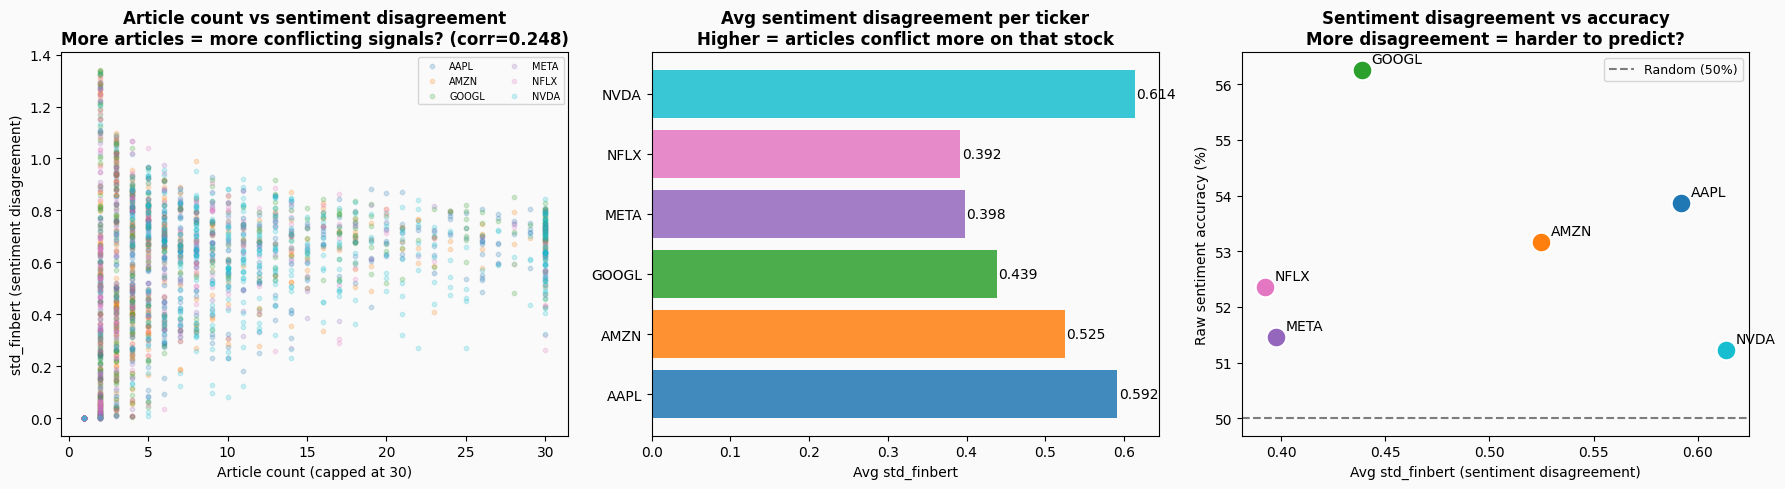

Volume noise summary:
Ticker      Avg/day    Avg std    Raw acc
------------------------------------------
AAPL           11.7      0.592      53.9%
AMZN            7.6      0.525      53.2%
GOOGL           7.4      0.439      56.3%
META            4.6      0.398      51.5%
NFLX            6.1      0.392      52.4%
NVDA           14.8      0.614      51.2%

Correlation — article count vs std_finbert: 0.248
Higher correlation = more volume = more noise confirmed


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 — Article count vs std_finbert (all tickers)
ax = axes[0]
for ticker in TICKERS:
    d = df_clean[df_clean['ticker']==ticker]
    ax.scatter(d['article_count'].clip(upper=30),
               d['std_finbert'],
               alpha=0.2, s=10,
               color=TICKER_COLORS[ticker], label=ticker)
corr = df_clean['article_count'].corr(df_clean['std_finbert'])
ax.set_xlabel('Article count (capped at 30)')
ax.set_ylabel('std_finbert (sentiment disagreement)')
ax.set_title(f'Article count vs sentiment disagreement\n'
             f'More articles = more conflicting signals? (corr={corr:.3f})',
             fontweight='bold')
ax.legend(fontsize=7, ncol=2)

# Panel 2 — Avg std_finbert per ticker
ax = axes[1]
avg_std = [df_clean[df_clean['ticker']==t]['std_finbert'].mean()
           for t in TICKERS]
bars = ax.barh(TICKERS, avg_std,
               color=[TICKER_COLORS[t] for t in TICKERS], alpha=0.85)
ax.set_xlabel('Avg std_finbert')
ax.set_title('Avg sentiment disagreement per ticker\n'
             'Higher = articles conflict more on that stock',
             fontweight='bold')
for bar, val in zip(bars, avg_std):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

# Panel 3 — std_finbert vs raw accuracy per ticker
ax = axes[2]
for ticker in TICKERS:
    ax.scatter(
        df_clean[df_clean['ticker']==ticker]['std_finbert'].mean(),
        raw_acc[ticker],
        s=200, color=TICKER_COLORS[ticker],
        zorder=5, edgecolors='white', linewidths=1.5
    )
    ax.annotate(ticker,
                (df_clean[df_clean['ticker']==ticker]['std_finbert'].mean(),
                 raw_acc[ticker]),
                textcoords='offset points', xytext=(7, 5), fontsize=10)
ax.axhline(y=50, color='black', linewidth=1.5,
           linestyle='--', alpha=0.5, label='Random (50%)')
ax.set_xlabel('Avg std_finbert (sentiment disagreement)')
ax.set_ylabel('Raw sentiment accuracy (%)')
ax.set_title('Sentiment disagreement vs accuracy\n'
             'More disagreement = harder to predict?',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Volume noise summary:')
print(f"{'Ticker':<8} {'Avg/day':>10} {'Avg std':>10} "
      f"{'Raw acc':>10}")
print('-'*42)
for ticker, avg, std_val, acc in zip(
    TICKERS,
    [avg_arts[t] for t in TICKERS],
    avg_std,
    [raw_acc[t] for t in TICKERS]
):
    print(f'{ticker:<8} {avg:>10.1f} {std_val:>10.3f} {acc:>9.1f}%')

print(f'\nCorrelation — article count vs std_finbert: {corr:.3f}')
print(f'Higher correlation = more volume = more noise confirmed')

More articles per day → more conflicting signals → higher sentiment disagreement

downward trend confirmed — more disagreement = lower raw accuracy

## Disagreement days

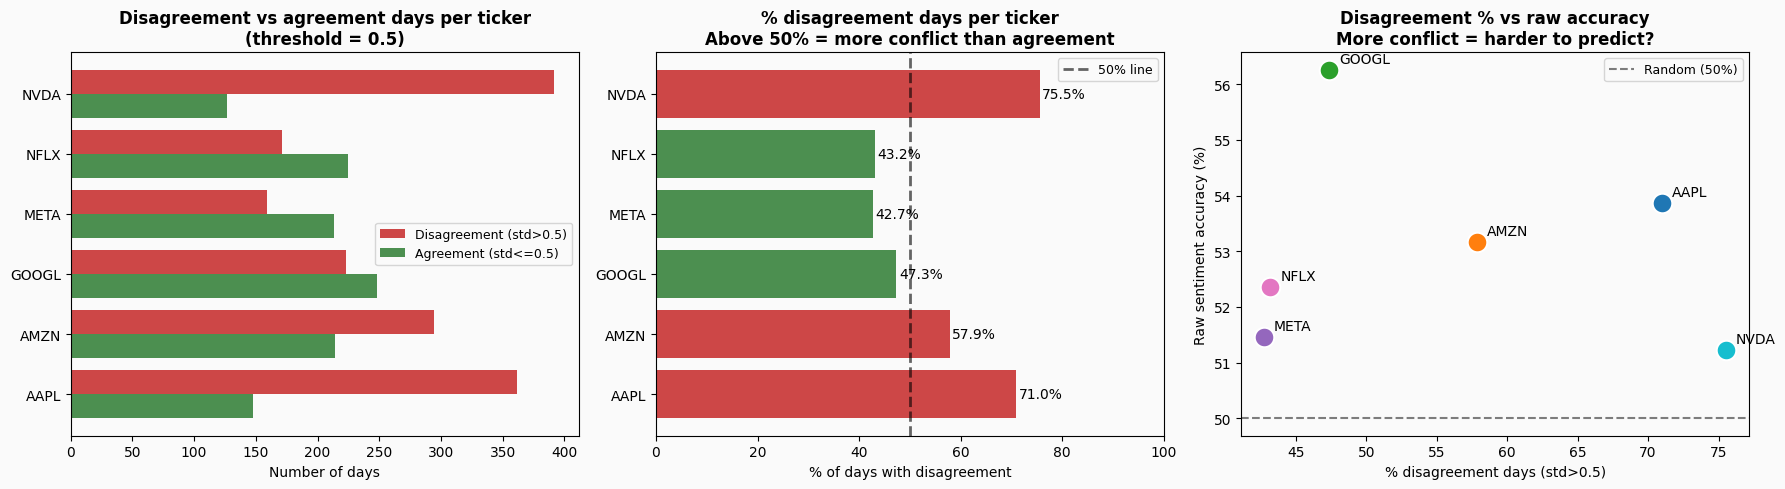

Disagreement analysis (threshold > 0.5):
Ticker     Agree days   Disagree days   % disagree    Raw acc
------------------------------------------------------------
AAPL              148             362        71.0%      53.9%
AMZN              214             294        57.9%      53.2%
GOOGL             248             223        47.3%      56.3%
META              213             159        42.7%      51.5%
NFLX              225             171        43.2%      52.4%
NVDA              127             392        75.5%      51.2%


In [ ]:
THRESHOLD = 0.5

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 — Disagreement days per ticker
ax = axes[0]
disagree_counts = []
agree_counts    = []
for ticker in TICKERS:
    d        = df_clean[df_clean['ticker']==ticker]
    disagree = (d['std_finbert'] > THRESHOLD).sum()
    agree    = (d['std_finbert'] <= THRESHOLD).sum()
    disagree_counts.append(disagree)
    agree_counts.append(agree)

x = np.arange(len(TICKERS))
ax.barh(x+0.2, disagree_counts, 0.4,
        label=f'Disagreement (std>{THRESHOLD})',
        color=DOWN_COLOR, alpha=0.85)
ax.barh(x-0.2, agree_counts, 0.4,
        label=f'Agreement (std<={THRESHOLD})',
        color=UP_COLOR, alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(TICKERS)
ax.set_xlabel('Number of days')
ax.set_title(f'Disagreement vs agreement days per ticker\n'
             f'(threshold = {THRESHOLD})',
             fontweight='bold')
ax.legend(fontsize=9)

# Panel 2 — % disagreement days per ticker
ax = axes[1]
disagree_pct = [d/(d+a)*100 for d, a in
                zip(disagree_counts, agree_counts)]
colors = [DOWN_COLOR if p>50 else UP_COLOR for p in disagree_pct]
bars = ax.barh(TICKERS, disagree_pct, color=colors, alpha=0.85)
ax.axvline(x=50, color='black', linewidth=2,
           linestyle='--', alpha=0.6, label='50% line')
ax.set_xlabel('% of days with disagreement')
ax.set_title('% disagreement days per ticker\n'
             'Above 50% = more conflict than agreement',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 100)
for bar, val in zip(bars, disagree_pct):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

# Panel 3 — Disagreement % vs raw accuracy
ax = axes[2]
for ticker, dpct, acc in zip(TICKERS, disagree_pct,
                              [raw_acc[t] for t in TICKERS]):
    ax.scatter(dpct, acc, s=200, color=TICKER_COLORS[ticker],
               zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate(ticker, (dpct, acc),
                textcoords='offset points', xytext=(7, 5), fontsize=10)
ax.axhline(y=50, color='black', linewidth=1.5,
           linestyle='--', alpha=0.5, label='Random (50%)')
ax.set_xlabel(f'% disagreement days (std>{THRESHOLD})')
ax.set_ylabel('Raw sentiment accuracy (%)')
ax.set_title('Disagreement % vs raw accuracy\n'
             'More conflict = harder to predict?',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Disagreement analysis (threshold > {THRESHOLD}):')
print(f"{'Ticker':<8} {'Agree days':>12} {'Disagree days':>15} "
      f"{'% disagree':>12} {'Raw acc':>10}")
print('-'*60)
for ticker, d, a, dpct, acc in zip(
    TICKERS, disagree_counts, agree_counts,
    disagree_pct, [raw_acc[t] for t in TICKERS]
):
    print(f'{ticker:<8} {a:>12,} {d:>15,} '
          f'{dpct:>11.1f}% {acc:>9.1f}%')

## Signal quality

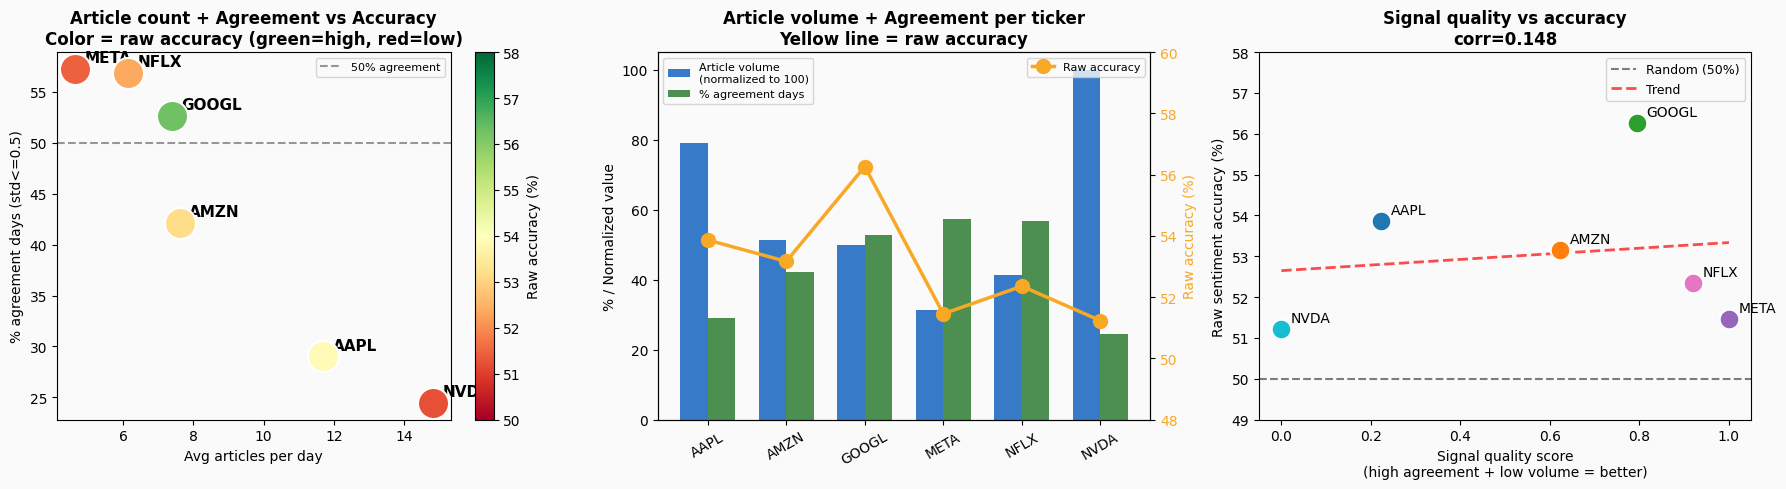

Signal quality analysis:
Ticker      Avg/day     Agree%   Signal quality    Raw acc
---------------------------------------------------------
AAPL           11.7      29.0%            0.222      53.9%
AMZN            7.6      42.1%            0.623      53.2%
GOOGL           7.4      52.7%            0.795      56.3%
META            4.6      57.3%            1.000      51.5%
NFLX            6.1      56.8%            0.919      52.4%
NVDA           14.8      24.5%            0.000      51.2%

Correlation signal quality vs accuracy: 0.148


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

avg_arts_t  = {t: df_clean[(df_clean['ticker']==t) &
                            (df_clean['article_count']>0)]['article_count'].mean()
               for t in TICKERS}
agree_pct_t = {t: (df_clean[df_clean['ticker']==t]['std_finbert'] <= 0.5).mean()*100
               for t in TICKERS}
acc_t       = {t: raw_acc[t] for t in TICKERS}

# Panel 1 — Scatter: article count vs agreement % colored by accuracy
ax = axes[0]
for ticker in TICKERS:
    sc = ax.scatter(
        avg_arts_t[ticker],
        agree_pct_t[ticker],
        s=500,
        c=acc_t[ticker],
        cmap='RdYlGn',
        vmin=50, vmax=58,
        zorder=5,
        edgecolors='white',
        linewidths=1.5
    )
    ax.annotate(ticker,
                (avg_arts_t[ticker], agree_pct_t[ticker]),
                textcoords='offset points',
                xytext=(7, 5), fontsize=11, fontweight='bold')
plt.colorbar(sc, ax=ax, label='Raw accuracy (%)')
ax.axhline(y=50, color='black', linewidth=1.5,
           linestyle='--', alpha=0.4, label='50% agreement')
ax.set_xlabel('Avg articles per day')
ax.set_ylabel('% agreement days (std<=0.5)')
ax.set_title('Article count + Agreement vs Accuracy\n'
             'Color = raw accuracy (green=high, red=low)',
             fontweight='bold')
ax.legend(fontsize=8)

# Panel 2 — Bar chart per ticker showing both metrics + accuracy
ax = axes[1]
x     = np.arange(len(TICKERS))
width = 0.35

arts_pct = [avg_arts_t[t] / max(avg_arts_t.values()) * 100
            for t in TICKERS]
agr_pct  = [agree_pct_t[t] for t in TICKERS]

bars1 = ax.bar(x - width/2, arts_pct, width,
               label='Article volume\n(normalized to 100)',
               color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + width/2, agr_pct, width,
               label='% agreement days',
               color=UP_COLOR, alpha=0.85)

ax2 = ax.twinx()
ax2.plot(x, [acc_t[t] for t in TICKERS], 'o-',
         color='#F9A825', linewidth=2.5,
         markersize=10, label='Raw accuracy', zorder=5)
ax2.set_ylabel('Raw accuracy (%)', color='#F9A825')
ax2.tick_params(axis='y', labelcolor='#F9A825')
ax2.set_ylim(48, 60)

ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=30)
ax.set_ylabel('% / Normalized value')
ax.set_title('Article volume + Agreement per ticker\n'
             'Yellow line = raw accuracy',
             fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax2.legend(fontsize=8, loc='upper right')

# Panel 3 — Combined signal quality score vs accuracy
ax = axes[2]

# High agreement + low volume = better signal quality
# So signal quality = agreement - normalized volume
arts_norm = np.array([avg_arts_t[t] for t in TICKERS])
arts_norm = (arts_norm - arts_norm.min()) / (arts_norm.max() - arts_norm.min())
agr_norm  = np.array([agree_pct_t[t] for t in TICKERS])
agr_norm  = (agr_norm - agr_norm.min()) / (agr_norm.max() - agr_norm.min())

# Signal quality = more agreement + less volume
signal_quality = (agr_norm + (1 - arts_norm)) / 2

for i, ticker in enumerate(TICKERS):
    ax.scatter(signal_quality[i], acc_t[ticker],
               s=200, color=TICKER_COLORS[ticker],
               zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate(ticker, (signal_quality[i], acc_t[ticker]),
                textcoords='offset points', xytext=(7, 5), fontsize=10)
ax.axhline(y=50, color='black', linewidth=1.5,
           linestyle='--', alpha=0.5, label='Random (50%)')

z      = np.polyfit(signal_quality, [acc_t[t] for t in TICKERS], 1)
p      = np.poly1d(z)
x_line = np.linspace(signal_quality.min(), signal_quality.max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2,
        alpha=0.7, label='Trend')
corr_signal = np.corrcoef(
    signal_quality, [acc_t[t] for t in TICKERS]
)[0, 1]
ax.set_xlabel('Signal quality score\n(high agreement + low volume = better)')
ax.set_ylabel('Raw sentiment accuracy (%)')
ax.set_title(f'Signal quality vs accuracy\n'
             f'corr={corr_signal:.3f}',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(49, 58)

plt.tight_layout()
plt.show()

print('Signal quality analysis:')
print(f"{'Ticker':<8} {'Avg/day':>10} {'Agree%':>10} "
      f"{'Signal quality':>16} {'Raw acc':>10}")
print('-'*57)
for i, ticker in enumerate(TICKERS):
    print(f'{ticker:<8} {avg_arts_t[ticker]:>10.1f} '
          f'{agree_pct_t[ticker]:>9.1f}% '
          f'{signal_quality[i]:>16.3f} '
          f'{acc_t[ticker]:>9.1f}%')
print(f'\nCorrelation signal quality vs accuracy: {corr_signal:.3f}')

In [ ]:
# arts_norm = (arts_values - min) / (max - min)
# agr_norm = (agr_values - min) / (max - min)
# signal_quality = (agr_norm + (1 - arts_norm)) / 2


In [ ]:
# GOOGL: blue ≈ green (50 vs 52) — balanced volume and agreement → best accuracy
# NVDA : blue >> green (100 vs 24) — volume overwhelms agreement → worst accuracy
# META : blue << green (31 vs 57) — low volume, good agreement but missing days → poor accuracy

In [ ]:
# When article volume and agreement are balanced — neither too high nor too low — sentiment accuracy is best. GOOGL hits that balance naturally.
# NVDA and META sit at opposite extremes.

## Question 4 — What does the sentiment look like?

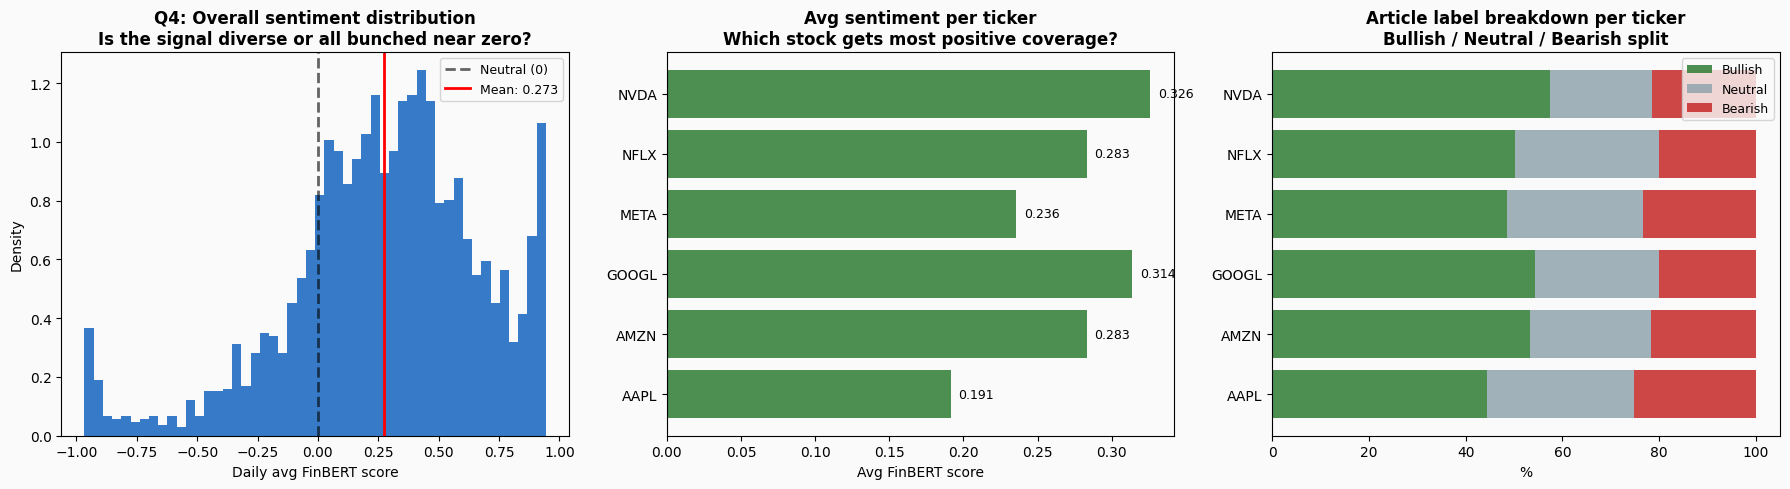

Sentiment summary:
Ticker    Avg score    Bullish    Neutral    Bearish
--------------------------------------------------
AAPL          0.191      44.5%      30.2%      25.3%
AMZN          0.283      53.2%      25.2%      21.6%
GOOGL         0.314      54.4%      25.7%      19.9%
META          0.236      48.6%      28.0%      23.4%
NFLX          0.283      50.2%      29.7%      20.1%
NVDA          0.326      57.4%      21.1%      21.4%

Overall mean score : 0.273
% positive days    : 79.5%
% negative days    : 20.5%
% neutral days     : 0.0%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 — Overall score distribution
ax = axes[0]
scores = df_clean['avg_finbert'].dropna()
ax.hist(scores, bins=50, color='#1565C0', alpha=0.85, density=True)
ax.axvline(x=0, color='black', linewidth=2,
           linestyle='--', alpha=0.6, label='Neutral (0)')
ax.axvline(x=scores.mean(), color='red', linewidth=2,
           linestyle='-', label=f'Mean: {scores.mean():.3f}')
ax.set_xlabel('Daily avg FinBERT score')
ax.set_ylabel('Density')
ax.set_title('Q4: Overall sentiment distribution\n'
             'Is the signal diverse or all bunched near zero?',
             fontweight='bold')
ax.legend(fontsize=9)

# Panel 2 — Avg score per ticker
ax = axes[1]
avg_scores = [df_clean[df_clean['ticker']==t]['avg_finbert'].mean()
              for t in TICKERS]
colors_s   = [UP_COLOR if s>0 else DOWN_COLOR for s in avg_scores]
bars = ax.barh(TICKERS, avg_scores, color=colors_s, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Avg FinBERT score')
ax.set_title('Avg sentiment per ticker\n'
             'Which stock gets most positive coverage?',
             fontweight='bold')
for bar, val in zip(bars, avg_scores):
    ax.text(val+(0.005 if val>=0 else -0.005),
            bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9,
            ha='left' if val>=0 else 'right')

# Panel 3 — Label breakdown per ticker
ax = axes[2]
bull = [df_clean[df_clean['ticker']==t]['bullish_ratio'].mean()*100
        for t in TICKERS]
bear = [df_clean[df_clean['ticker']==t]['bearish_ratio'].mean()*100
        for t in TICKERS]
neu  = [100-b-br for b, br in zip(bull, bear)]
x    = np.arange(len(TICKERS))
ax.barh(x, bull, label='Bullish', color=UP_COLOR,   alpha=0.85)
ax.barh(x, neu,  label='Neutral', color='#90A4AE',  alpha=0.85,
        left=bull)
ax.barh(x, bear, label='Bearish', color=DOWN_COLOR, alpha=0.85,
        left=[b+n for b, n in zip(bull, neu)])
ax.set_yticks(x)
ax.set_yticklabels(TICKERS)
ax.set_xlabel('%')
ax.set_title('Article label breakdown per ticker\n'
             'Bullish / Neutral / Bearish split',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Sentiment summary:')
print(f"{'Ticker':<8} {'Avg score':>10} {'Bullish':>10} "
      f"{'Neutral':>10} {'Bearish':>10}")
print('-'*50)
for t, avg, b, n, br in zip(TICKERS, avg_scores, bull, neu, bear):
    print(f'{t:<8} {avg:>10.3f} {b:>9.1f}% {n:>9.1f}% {br:>9.1f}%')
print(f'\nOverall mean score : {scores.mean():.3f}')
print(f'% positive days    : {(scores>0).mean()*100:.1f}%')
print(f'% negative days    : {(scores<0).mean()*100:.1f}%')
print(f'% neutral days     : {(scores==0).mean()*100:.1f}%')

In [ ]:
# 79.5% positive days but stocks only UP 53.6% of days. Gap of 25.9% — news is structurally over-optimistic. Positive sentiment alone cannot be taken at face value as a buy signal. This is the fundamental reason raw sentiment accuracy is only 53.1%.

## Q5 — Does sentiment predict price?

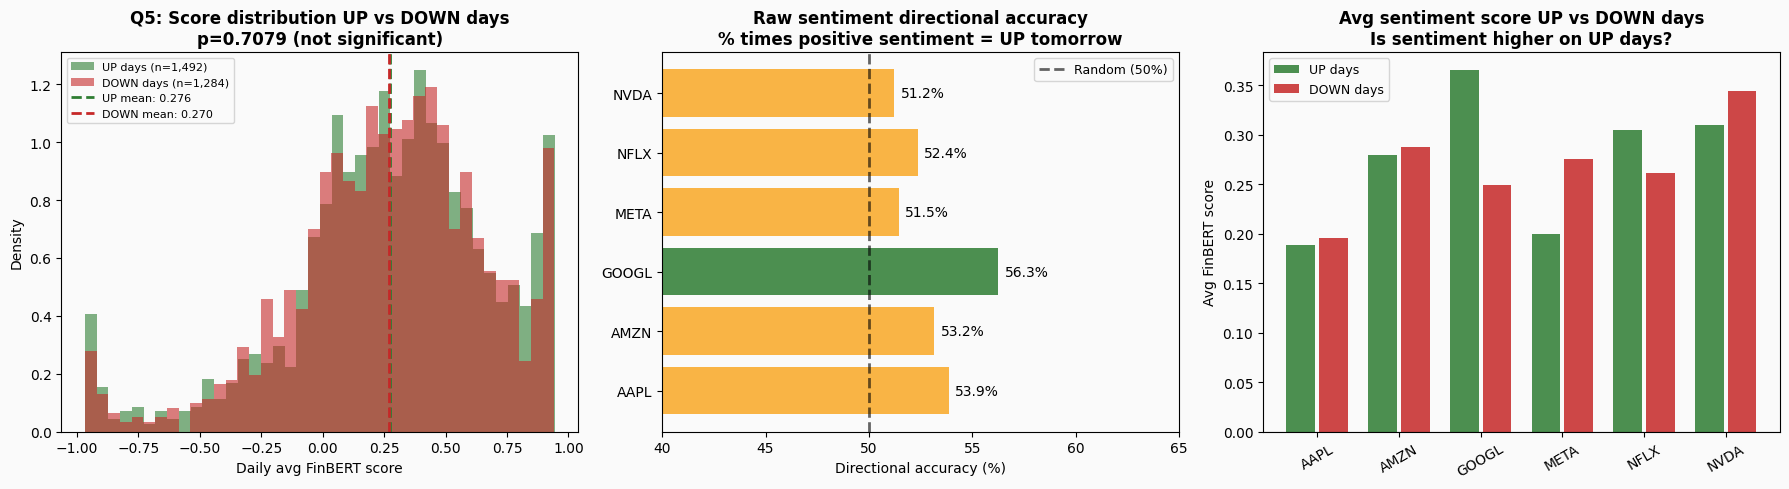

Sentiment vs price direction:
  UP day avg score  : 0.2758
  DOWN day avg score: 0.2701
  Difference        : 0.0057
  t-statistic       : 0.375
  p-value           : 0.707937
  Significant       : NO

Directional accuracy per ticker:
  AAPL: 53.9%  
  AMZN: 53.2%  
  GOOGL: 56.3% ✓
  META: 51.5%  
  NFLX: 52.4%  
  NVDA: 51.2%  

  Overall: 53.1%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 — Score distribution UP vs DOWN days
ax = axes[0]
up_s   = df_clean[df_clean['target']==1]['avg_finbert']
down_s = df_clean[df_clean['target']==0]['avg_finbert']
ax.hist(up_s,   bins=40, alpha=0.6, color=UP_COLOR,
        label=f'UP days (n={len(up_s):,})',   density=True)
ax.hist(down_s, bins=40, alpha=0.6, color=DOWN_COLOR,
        label=f'DOWN days (n={len(down_s):,})', density=True)
ax.axvline(x=up_s.mean(),   color=UP_COLOR,   linewidth=2,
           linestyle='--', label=f'UP mean: {up_s.mean():.3f}')
ax.axvline(x=down_s.mean(), color=DOWN_COLOR, linewidth=2,
           linestyle='--', label=f'DOWN mean: {down_s.mean():.3f}')
t, p = stats.ttest_ind(up_s, down_s)
ax.set_title(f'Q5: Score distribution UP vs DOWN days\n'
             f'p={p:.4f} ({"SIGNIFICANT" if p<0.05 else "not significant"})',
             fontweight='bold')
ax.set_xlabel('Daily avg FinBERT score')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Panel 2 — Directional accuracy per ticker
ax = axes[1]
dir_acc = []
for ticker in TICKERS:
    d     = df_clean[df_clean['ticker']==ticker]
    d_sig = d[d['avg_finbert'].abs()>0.05]
    dir_acc.append(d_sig['correct'].mean()*100
                   if len(d_sig)>0 else 50.0)
colors_da = [UP_COLOR if a>=55 else '#F9A825' if a>=50
             else DOWN_COLOR for a in dir_acc]
bars = ax.barh(TICKERS, dir_acc, color=colors_da, alpha=0.85)
ax.axvline(x=50, color='black', linewidth=2,
           linestyle='--', alpha=0.6, label='Random (50%)')
ax.set_xlabel('Directional accuracy (%)')
ax.set_title('Raw sentiment directional accuracy\n'
             '% times positive sentiment = UP tomorrow',
             fontweight='bold')
ax.set_xlim(40, 65)
ax.legend(fontsize=9)
for bar, val in zip(bars, dir_acc):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

# Panel 3 — Avg score UP vs DOWN per ticker
ax = axes[2]
up_m   = [df_clean[(df_clean['ticker']==t)&
                   (df_clean['target']==1)]['avg_finbert'].mean()
          for t in TICKERS]
down_m = [df_clean[(df_clean['ticker']==t)&
                   (df_clean['target']==0)]['avg_finbert'].mean()
          for t in TICKERS]
x = np.arange(len(TICKERS))
ax.bar(x-0.2, up_m,   0.35, label='UP days',
       color=UP_COLOR,   alpha=0.85)
ax.bar(x+0.2, down_m, 0.35, label='DOWN days',
       color=DOWN_COLOR, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=30)
ax.set_ylabel('Avg FinBERT score')
ax.set_title('Avg sentiment score UP vs DOWN days\n'
             'Is sentiment higher on UP days?',
             fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

print('Sentiment vs price direction:')
print(f'  UP day avg score  : {up_s.mean():.4f}')
print(f'  DOWN day avg score: {down_s.mean():.4f}')
print(f'  Difference        : {up_s.mean()-down_s.mean():.4f}')
print(f'  t-statistic       : {t:.3f}')
print(f'  p-value           : {p:.6f}')
print(f'  Significant       : {"YES" if p<0.05 else "NO"}')
print()
print('Directional accuracy per ticker:')
for ticker, acc in zip(TICKERS, dir_acc):
    beat = '✓' if acc>=55 else ' '
    print(f'  {ticker}: {acc:.1f}% {beat}')
print(f'\n  Overall: {sum(dir_acc)/len(dir_acc):.1f}%')

In [ ]:
# H0: mean(UP sentiment) = mean(DOWN sentiment)
# H1: mean(UP sentiment) ≠ mean(DOWN sentiment)
# p = 0.7079
# p < 0.05 → reject H0 → sentiment predicts price ✓
# p >= 0.05 → fail to reject H0 → sentiment does NOT predict price ✗

# Our result: p = 0.7079 → fail to reject H0

In [ ]:
# Raw FinBERT sentiment alone cannot reliably predict next-day stock direction. p=0.71 — not significant. The signal exists but is too weak to use directly.
# this directly justifies why we needed feature engineering, machine learning, and per-ticker models.

## Q6 — Article count vs accuracy

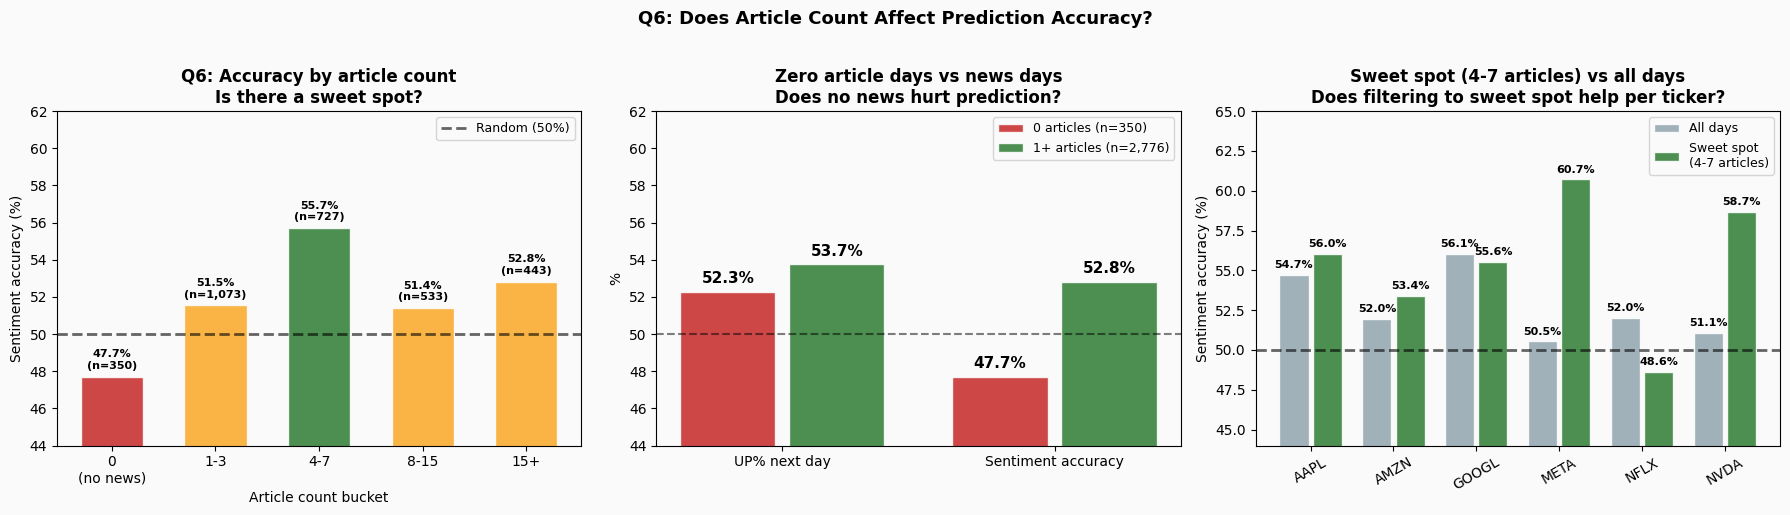

Accuracy by article count bucket:
Bucket         Accuracy    Count
--------------------------------
0 (no news)       47.7%      350
1-3               51.5%    1,073
4-7               55.7%      727 ← sweet spot
8-15              51.4%      533
15+               52.8%      443

Zero article days (n=350):
  UP% next day  : 52.3%
  Sentiment acc : 47.7%

News days (n=2,776):
  UP% next day  : 53.7%
  Sentiment acc : 52.8%

Sweet spot (4-7 articles) vs all days per ticker:
Ticker     All days   Sweet spot     Gain
------------------------------------------
AAPL          54.7%        56.0%    +1.3%
AMZN          52.0%        53.4%    +1.4%
GOOGL         56.1%        55.6%    -0.5%
META          50.5%        60.7%   +10.2%
NFLX          52.0%        48.6%    -3.4%
NVDA          51.1%        58.7%    +7.6%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Prep data ─────────────────────────────────────────────────────────────────
# Zero article days — from full df before dropna
zero_art = df[(df['article_count']==0) |
              (df['avg_finbert'].isna())].dropna(subset=['target'])
has_art  = df_clean[df_clean['article_count']>0]

df_clean['article_bucket'] = pd.cut(
    df_clean['article_count'],
    bins=[-1, 0, 3, 7, 15, 500],
    labels=['0\n(no news)', '1-3', '4-7', '8-15', '15+']
)

# ── Panel 1 — Accuracy by article count bucket ────────────────────────────────
ax = axes[0]
bucket_labels = ['1-3', '4-7', '8-15', '15+']
bucket_keys   = ['1-3', '4-7', '8-15', '15+']
b_acc = []
b_cnt = []

# Add zero article days manually
zero_acc = zero_art['correct'].mean()*100 if len(zero_art)>0 else 0
b_acc_all = [zero_acc]
b_cnt_all = [len(zero_art)]
b_lbl_all = ['0\n(no news)']

for bk in bucket_keys:
    d = df_clean[df_clean['article_bucket']==bk]
    b_acc_all.append(d['correct'].mean()*100 if len(d)>0 else 0)
    b_cnt_all.append(len(d))
    b_lbl_all.append(bk)

colors_b = [UP_COLOR if a>=55 else '#F9A825' if a>=50
            else DOWN_COLOR for a in b_acc_all]
bars = ax.bar(b_lbl_all, b_acc_all, color=colors_b,
              alpha=0.85, edgecolor='white', width=0.6)
ax.axhline(y=50, color='black', linewidth=2,
           linestyle='--', alpha=0.6, label='Random (50%)')
ax.set_ylabel('Sentiment accuracy (%)')
ax.set_xlabel('Article count bucket')
ax.set_title('Q6: Accuracy by article count\n'
             'Is there a sweet spot?',
             fontweight='bold')
ax.set_ylim(44, 62)
ax.legend(fontsize=9)
for bar, val, cnt in zip(bars, b_acc_all, b_cnt_all):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3,
            f'{val:.1f}%\n(n={cnt:,})',
            ha='center', va='bottom', fontsize=8,
            fontweight='bold')

# ── Panel 2 — Zero article vs news days ───────────────────────────────────────
ax = axes[1]
zero_up  = zero_art['target'].mean()*100
has_up   = has_art['target'].mean()*100
zero_acc_val = zero_art['correct'].mean()*100 if len(zero_art)>0 else 0
has_acc_val  = has_art['correct'].mean()*100

x          = np.arange(2)
categories = ['UP% next day', 'Sentiment accuracy']
zero_vals  = [zero_up,       zero_acc_val]
has_vals   = [has_up,        has_acc_val]

bars1 = ax.bar(x-0.2, zero_vals, 0.35,
               label=f'0 articles (n={len(zero_art):,})',
               color=DOWN_COLOR, alpha=0.85, edgecolor='white')
bars2 = ax.bar(x+0.2, has_vals,  0.35,
               label=f'1+ articles (n={len(has_art):,})',
               color=UP_COLOR,   alpha=0.85, edgecolor='white')
ax.axhline(y=50, color='black', linewidth=1.5,
           linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('%')
ax.set_title('Zero article days vs news days\n'
             'Does no news hurt prediction?',
             fontweight='bold')
ax.set_ylim(44, 62)
ax.legend(fontsize=9)
for bar, val in zip(list(bars1)+list(bars2), zero_vals+has_vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# ── Panel 3 — Per ticker accuracy at sweet spot vs overall ────────────────────
ax = axes[2]
sweet_acc   = []
overall_acc = []
for ticker in TICKERS:
    d_sweet   = df_clean[(df_clean['ticker']==ticker) &
                         (df_clean['article_bucket']=='4-7')]
    d_all     = df_clean[df_clean['ticker']==ticker]
    sweet_acc.append(d_sweet['correct'].mean()*100
                     if len(d_sweet)>10 else 0)
    overall_acc.append(d_all['correct'].mean()*100)

x = np.arange(len(TICKERS))
bars3 = ax.bar(x-0.2, overall_acc, 0.35,
               label='All days',
               color='#90A4AE', alpha=0.85, edgecolor='white')
bars4 = ax.bar(x+0.2, sweet_acc,  0.35,
               label='Sweet spot\n(4-7 articles)',
               color=UP_COLOR,   alpha=0.85, edgecolor='white')
ax.axhline(y=50, color='black', linewidth=2,
           linestyle='--', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=30)
ax.set_ylabel('Sentiment accuracy (%)')
ax.set_title('Sweet spot (4-7 articles) vs all days\n'
             'Does filtering to sweet spot help per ticker?',
             fontweight='bold')
ax.set_ylim(44, 65)
ax.legend(fontsize=9)
for bar, val in zip(list(bars3)+list(bars4),
                    overall_acc+sweet_acc):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.3,
                f'{val:.1f}%',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold')

plt.suptitle('Q6: Does Article Count Affect Prediction Accuracy?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Accuracy by article count bucket:')
print(f"{'Bucket':<12} {'Accuracy':>10} {'Count':>8}")
print('-'*32)
for lbl, acc, cnt in zip(b_lbl_all, b_acc_all, b_cnt_all):
    marker = ' ← sweet spot' if '4-7' in lbl else ''
    print(f"{lbl.replace(chr(10),' '):<12} "
          f"{acc:>9.1f}% {cnt:>8,}{marker}")

print(f'\nZero article days (n={len(zero_art):,}):')
print(f'  UP% next day  : {zero_up:.1f}%')
print(f'  Sentiment acc : {zero_acc_val:.1f}%')
print(f'\nNews days (n={len(has_art):,}):')
print(f'  UP% next day  : {has_up:.1f}%')
print(f'  Sentiment acc : {has_acc_val:.1f}%')

print(f'\nSweet spot (4-7 articles) vs all days per ticker:')
print(f"{'Ticker':<8} {'All days':>10} {'Sweet spot':>12} {'Gain':>8}")
print('-'*42)
for ticker, ov, sw in zip(TICKERS, overall_acc, sweet_acc):
    gain = sw - ov if sw > 0 else 0
    print(f'{ticker:<8} {ov:>9.1f}% {sw:>11.1f}% {gain:>+7.1f}%')

In [ ]:
# UP% is nearly identical — the market goes up at roughly the same rate regardless of whether there were articles.
# But sentiment accuracy drops 5.1 percentage points on zero article days. Prices behave normally but the neutral fill makes predictions worse.

In [ ]:
# META and NVDA benefit most from the sweet spot — +10.2% and +7.6%. This directly confirms the volume noise theory.
# On the rare days when META has exactly 4-7 focused articles the signal is clean and reliable.
# On days when NVDA drops from its typical 14.8 down to 4-7 articles the conflicting signals reduce and the prediction improves dramatically.
# GOOGL loses -0.5% — already sits near the sweet spot naturally so filtering further does not help.
# NFLX loses -3.4% — too few days in the 4-7 bucket to be statistically reliable. Small sample size effect.

## Q7 — Does Alpha Vantage prescore agree with FinBERT?

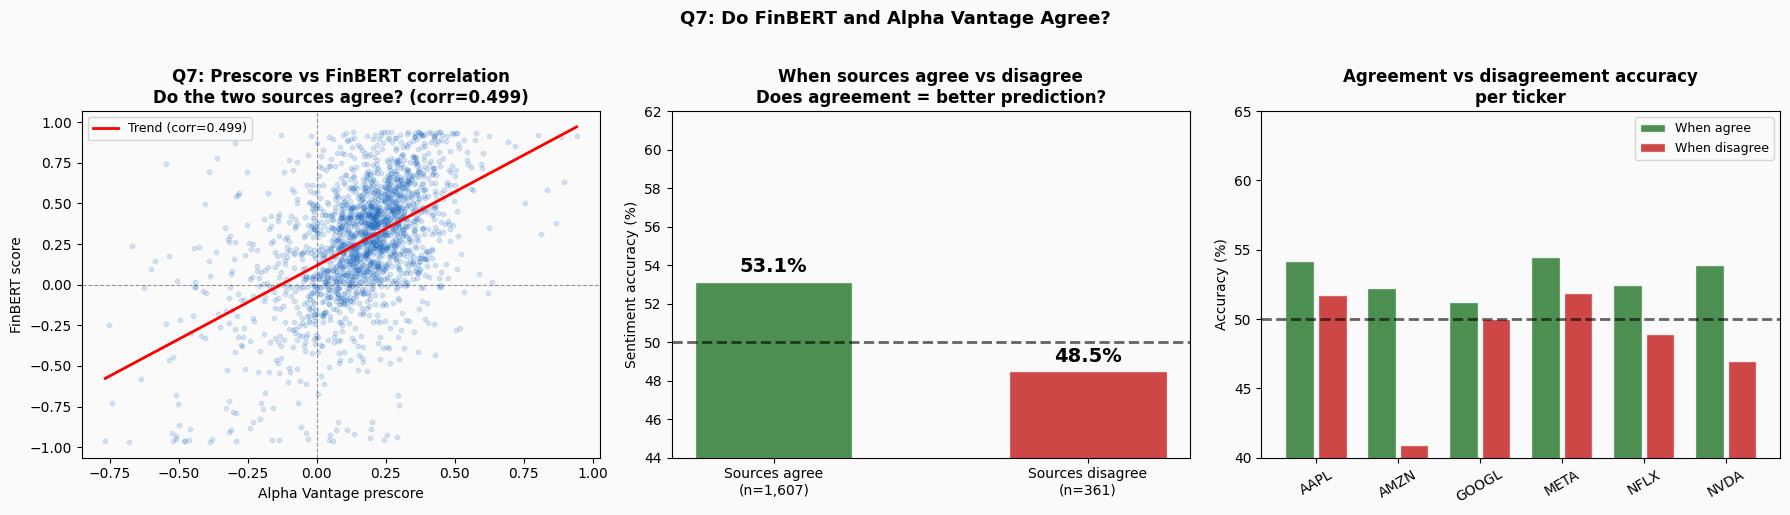

FinBERT vs Prescore correlation: 0.4989

Overall agreement rate: 81.7%

Accuracy when sources agree   : 53.1% (n=1,607)
Accuracy when sources disagree: 48.5% (n=361)

Per ticker agreement rate:
  AAPL: 78.7% agreement
  AMZN: 81.6% agreement
  GOOGL: 80.4% agreement
  META: 79.6% agreement
  NFLX: 82.6% agreement
  NVDA: 86.8% agreement


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_both = df_clean.dropna(subset=['avg_finbert', 'avg_prescore'])

# Panel 1 — Scatter: prescore vs finbert
ax = axes[0]
ax.scatter(df_both['avg_prescore'], df_both['avg_finbert'],
           alpha=0.15, s=10, color='#1565C0')
corr = df_both['avg_finbert'].corr(df_both['avg_prescore'])
m, b = np.polyfit(df_both['avg_prescore'],
                  df_both['avg_finbert'], 1)
x_line = np.linspace(df_both['avg_prescore'].min(),
                     df_both['avg_prescore'].max(), 100)
ax.plot(x_line, m*x_line+b, 'r-', linewidth=2,
        label=f'Trend (corr={corr:.3f})')
ax.axhline(y=0, color='black', linewidth=0.8,
           linestyle='--', alpha=0.4)
ax.axvline(x=0, color='black', linewidth=0.8,
           linestyle='--', alpha=0.4)
ax.set_xlabel('Alpha Vantage prescore')
ax.set_ylabel('FinBERT score')
ax.set_title(f'Q7: Prescore vs FinBERT correlation\n'
             f'Do the two sources agree? (corr={corr:.3f})',
             fontweight='bold')
ax.legend(fontsize=9)

# Panel 2 — Agreement vs disagreement accuracy
ax = axes[1]
# Agreement = both positive or both negative
df_both['sources_agree'] = (
    (df_both['avg_finbert'] > 0) == (df_both['avg_prescore'] > 0)
).astype(int)

agree_acc   = df_both[df_both['sources_agree']==1]['correct'].mean()*100
disagree_acc = df_both[df_both['sources_agree']==0]['correct'].mean()*100
agree_n     = (df_both['sources_agree']==1).sum()
disagree_n  = (df_both['sources_agree']==0).sum()

bars = ax.bar(
    [f'Sources agree\n(n={agree_n:,})',
     f'Sources disagree\n(n={disagree_n:,})'],
    [agree_acc, disagree_acc],
    color=[UP_COLOR, DOWN_COLOR],
    alpha=0.85, width=0.5, edgecolor='white'
)
ax.axhline(y=50, color='black', linewidth=2,
           linestyle='--', alpha=0.6)
ax.set_ylabel('Sentiment accuracy (%)')
ax.set_title('When sources agree vs disagree\n'
             'Does agreement = better prediction?',
             fontweight='bold')
ax.set_ylim(44, 62)
for bar, val in zip(bars, [agree_acc, disagree_acc]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontsize=14, fontweight='bold')

# Panel 3 — Per ticker agreement rate and accuracy
ax = axes[2]
agree_rates = []
acc_agree   = []
acc_disagree = []
for ticker in TICKERS:
    d = df_both[df_both['ticker']==ticker]
    agree = ((d['avg_finbert']>0) == (d['avg_prescore']>0)).mean()*100
    agree_rates.append(agree)
    acc_agree.append(
        d[((d['avg_finbert']>0)==(d['avg_prescore']>0))]['correct'].mean()*100
    )
    acc_disagree.append(
        d[((d['avg_finbert']>0)!=(d['avg_prescore']>0))]['correct'].mean()*100
    )

x = np.arange(len(TICKERS))
ax.bar(x-0.2, acc_agree,    0.35, label='When agree',
       color=UP_COLOR,   alpha=0.85, edgecolor='white')
ax.bar(x+0.2, acc_disagree, 0.35, label='When disagree',
       color=DOWN_COLOR, alpha=0.85, edgecolor='white')
ax.axhline(y=50, color='black', linewidth=2,
           linestyle='--', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=30)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Agreement vs disagreement accuracy\n'
             'per ticker',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(40, 65)

plt.suptitle('Q7: Do FinBERT and Alpha Vantage Agree?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'FinBERT vs Prescore correlation: {corr:.4f}')
print(f'\nOverall agreement rate: '
      f'{df_both["sources_agree"].mean()*100:.1f}%')
print(f'\nAccuracy when sources agree   : {agree_acc:.1f}% '
      f'(n={agree_n:,})')
print(f'Accuracy when sources disagree: {disagree_acc:.1f}% '
      f'(n={disagree_n:,})')
print(f'\nPer ticker agreement rate:')
for ticker, rate in zip(TICKERS, agree_rates):
    print(f'  {ticker}: {rate:.1f}% agreement')

## Q8 — Does sentiment momentum matter more than today's sentiment?

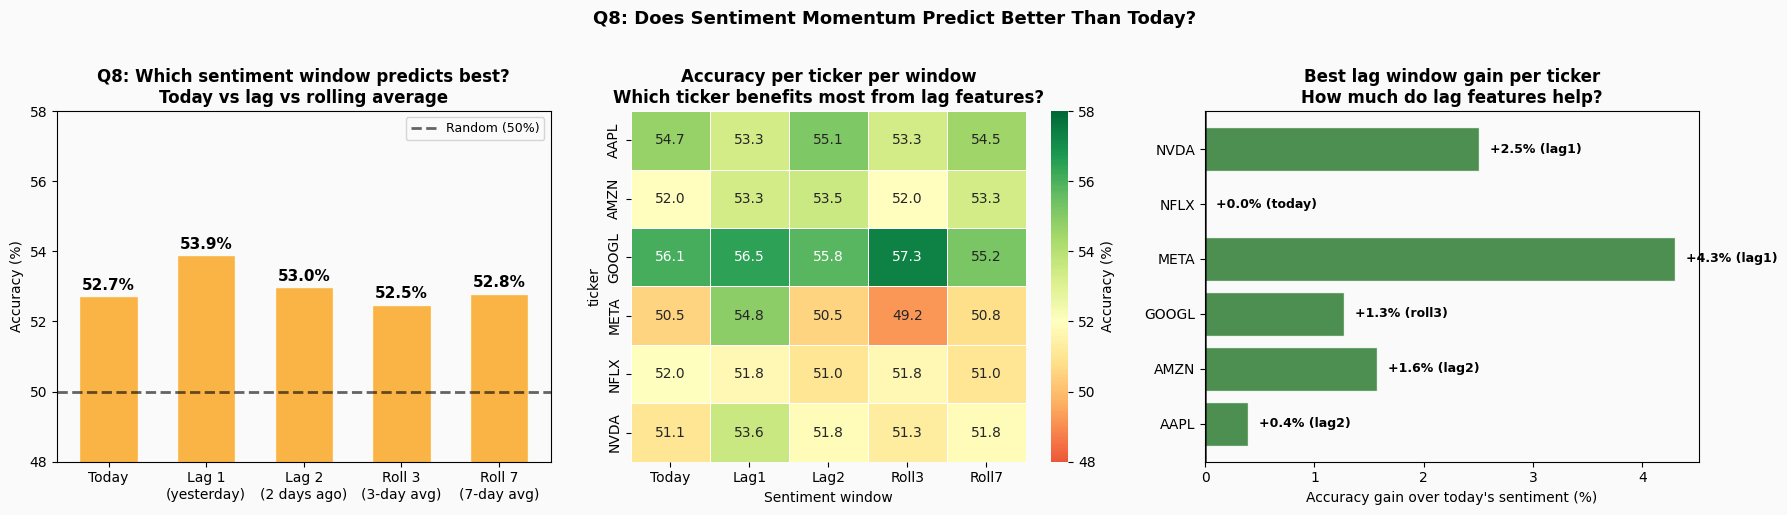

Accuracy per sentiment window:
Window       Accuracy
----------------------
today           52.7%
lag1            53.9% ← best
lag2            53.0%
roll3           52.5%
roll7           52.8%

Per ticker — best window:
Ticker      Today   Best acc  Best window     Gain
--------------------------------------------------
AAPL        54.7%      55.1%         lag2    +0.4%
AMZN        52.0%      53.5%         lag2    +1.6%
GOOGL       56.1%      57.3%        roll3    +1.3%
META        50.5%      54.8%         lag1    +4.3%
NFLX        52.0%      52.0%        today    +0.0%
NVDA        51.1%      53.6%         lag1    +2.5%


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate accuracy for different sentiment windows
results = []
for ticker in TICKERS:
    d = df_clean[df_clean['ticker']==ticker].sort_values('date').copy()

    # Today
    d['dir_today'] = (d['avg_finbert'] > 0).astype(int)
    d['correct_today'] = (d['dir_today'] == d['target']).astype(int)

    # Lag 1
    d['sent_lag1']    = d['avg_finbert'].shift(1)
    d['dir_lag1']     = (d['sent_lag1'] > 0).astype(int)
    d['correct_lag1'] = (d['dir_lag1'] == d['target']).astype(int)

    # Lag 2
    d['sent_lag2']    = d['avg_finbert'].shift(2)
    d['dir_lag2']     = (d['sent_lag2'] > 0).astype(int)
    d['correct_lag2'] = (d['dir_lag2'] == d['target']).astype(int)

    # 3-day rolling
    d['sent_roll3']    = d['avg_finbert'].rolling(3, min_periods=2).mean()
    d['dir_roll3']     = (d['sent_roll3'] > 0).astype(int)
    d['correct_roll3'] = (d['dir_roll3'] == d['target']).astype(int)

    # 7-day rolling
    d['sent_roll7']    = d['avg_finbert'].rolling(7, min_periods=3).mean()
    d['dir_roll7']     = (d['sent_roll7'] > 0).astype(int)
    d['correct_roll7'] = (d['dir_roll7'] == d['target']).astype(int)

    results.append({
        'ticker'  : ticker,
        'today'   : d['correct_today'].mean()*100,
        'lag1'    : d['correct_lag1'].dropna().mean()*100,
        'lag2'    : d['correct_lag2'].dropna().mean()*100,
        'roll3'   : d['correct_roll3'].dropna().mean()*100,
        'roll7'   : d['correct_roll7'].dropna().mean()*100,
    })

results_df = pd.DataFrame(results).set_index('ticker')

# Panel 1 — Overall accuracy per window
ax = axes[0]
windows     = ['today', 'lag1', 'lag2', 'roll3', 'roll7']
labels      = ['Today', 'Lag 1\n(yesterday)',
               'Lag 2\n(2 days ago)',
               'Roll 3\n(3-day avg)',
               'Roll 7\n(7-day avg)']
overall_acc = [results_df[w].mean() for w in windows]
colors_w    = [UP_COLOR if a>=54 else '#F9A825' if a>=52
               else DOWN_COLOR for a in overall_acc]
bars = ax.bar(labels, overall_acc, color=colors_w,
              alpha=0.85, edgecolor='white', width=0.6)
ax.axhline(y=50, color='black', linewidth=2,
           linestyle='--', alpha=0.6, label='Random (50%)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Q8: Which sentiment window predicts best?\n'
             'Today vs lag vs rolling average',
             fontweight='bold')
ax.set_ylim(48, 58)
ax.legend(fontsize=9)
for bar, val in zip(bars, overall_acc):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.1,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# Panel 2 — Per ticker heatmap
ax = axes[1]
heatmap_data = results_df[windows]
heatmap_data.columns = ['Today', 'Lag1', 'Lag2', 'Roll3', 'Roll7']
sns.heatmap(heatmap_data, ax=ax, cmap='RdYlGn',
            center=52, vmin=48, vmax=58,
            annot=True, fmt='.1f',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Accuracy (%)'})
ax.set_title('Accuracy per ticker per window\n'
             'Which ticker benefits most from lag features?',
             fontweight='bold')
ax.set_xlabel('Sentiment window')

# Panel 3 — Best window per ticker
ax = axes[2]
best_windows = results_df[windows].idxmax(axis=1)
best_acc     = results_df[windows].max(axis=1)
today_acc    = results_df['today']
gain         = best_acc - today_acc

colors_g = [UP_COLOR if g>0 else DOWN_COLOR for g in gain]
bars2 = ax.barh(TICKERS, gain, color=colors_g,
                alpha=0.85, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=2, alpha=0.7)
ax.set_xlabel('Accuracy gain over today\'s sentiment (%)')
ax.set_title('Best lag window gain per ticker\n'
             'How much do lag features help?',
             fontweight='bold')
for bar, val, ticker in zip(bars2, gain, TICKERS):
    best_w = best_windows[ticker]
    ax.text(val+(0.1 if val>=0 else -0.1),
            bar.get_y()+bar.get_height()/2,
            f'{val:+.1f}% ({best_w})',
            va='center', fontsize=9,
            ha='left' if val>=0 else 'right',
            fontweight='bold')

plt.suptitle('Q8: Does Sentiment Momentum Predict Better Than Today?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Accuracy per sentiment window:')
print(f"{'Window':<10} {'Accuracy':>10}")
print('-'*22)
for w, lbl, acc in zip(windows, labels, overall_acc):
    best = ' ← best' if acc==max(overall_acc) else ''
    print(f'{w:<10} {acc:>9.1f}%{best}')

print(f'\nPer ticker — best window:')
print(f"{'Ticker':<8} {'Today':>8} {'Best acc':>10} "
      f"{'Best window':>12} {'Gain':>8}")
print('-'*50)
for ticker in TICKERS:
    today  = results_df.loc[ticker, 'today']
    best_w = best_windows[ticker]
    best_a = best_acc[ticker]
    g      = best_a - today
    print(f'{ticker:<8} {today:>7.1f}% {best_a:>9.1f}% '
          f'{best_w:>12} {g:>+7.1f}%')

In [ ]:
# Q1 — Price history — NVDA +154%, GOOGL surprised at +134%
# Q2 — UP/DOWN balance — all tickers slightly UP-biased, dataset usable
# Q3 — Article coverage — NVDA 7,689 articles vs META 1,720, big quality gap
# Q3b — More data ≠ better accuracy — NVDA paradox confirmed
# Volume noise — corr=0.248, more articles = more conflict = weaker signal
# Disagreement days — NVDA 75.5% conflict days, GOOGL only 47.3%
# Signal quality — GOOGL sweet spot, two separate problems identified
# Q4 — Sentiment distribution — 79.5% positive but only 53.6% UP days, 25.9% gap
# Q5 — Raw sentiment cannot predict price — p=0.71, difference only 0.006
# Q6 — Sweet spot at 4-7 articles, zero article days 47.7% below random
# Q7 — FinBERT vs Alpha Vantage corr=0.499, disagreement days 48.5% below random
# Q8 — Lag1 best window at 53.9%, META gains most +4.3% from lag features